# N4 · Uncertainty → Decision — "So did it work or not?"

**Panel question** — asked by the **CRO/CCO** (with the Head of Data listening):
*"The geo-test shows +2% margin with a wide confidence interval crossing zero.
Did it work or not?"*

This is the single highest-leverage artefact in the prep programme: translating
a wide interval into a **decision** — expected value, bounded downside,
reversibility — instead of a verdict.

**Contract:** simulate a geo test with *known* true effect → show the naive
frequentist verdict failing → Bayesian reframe → £ decision → 60-second answer.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from _style import C, apply_style
apply_style()

rng = np.random.default_rng(42)

# --- Ground truth we control: the margin change DOES work (+2.0% contribution).
TRUE_EFFECT = 2.0          # percentage points of contribution uplift
N_T, N_C = 40, 40          # treated / control branches (a realistic geo test)
BRANCH_SD = 5.6            # branch-level noise on the % outcome (4 weeks of data)

# The panel scenario FIXES the observed result ("+2%, CI crossing zero"), so we
# standardise the simulated branches to hit it exactly — the randomness we care
# about is in the replays (§2) and the decision analysis (§4), not this draw.
def _standardise(x, mu, sd):
    return (x - x.mean()) / x.std(ddof=1) * sd + mu

treated = _standardise(rng.normal(0, 1, N_T), TRUE_EFFECT, BRANCH_SD)
control = _standardise(rng.normal(0, 1, N_C), 0.0, BRANCH_SD)

est = treated.mean() - control.mean()
se = np.sqrt(treated.var(ddof=1) / N_T + control.var(ddof=1) / N_C)
ci = (est - 1.96 * se, est + 1.96 * se)
print(f"Estimate: {est:+.2f}pp   SE: {se:.2f}pp   95% CI: [{ci[0]:+.2f}, {ci[1]:+.2f}]")
assert ci[0] < 0 < ci[1], "scenario premise: the CI must cross zero"

Estimate: +2.00pp   SE: 1.25pp   95% CI: [-0.45, +4.45]


## 1. The wrong answer

The interval crosses zero, so the standard verdict is *"not statistically
significant — it didn't work."* Watch what that verdict does to a true +2%.

In [2]:
t = est / se
p = 2 * (1 - stats.norm.cdf(abs(t)))
assert p > 0.05
print(f"t = {t:.2f}, p = {p:.3f}  ->  'NOT statistically significant'")
print("Naive conclusion: 'the change didn't work'  <-- WRONG (truth is +2.0pp)")

t = 1.60, p = 0.110  ->  'NOT statistically significant'
Naive conclusion: 'the change didn't work'  <-- WRONG (truth is +2.0pp)


## 2. Why it's wrong: under-powered ≠ null

Re-run the *identical* test in thousands of worlds where the true effect **is**
+2%. Count how often a perfectly-executed test still "fails."

True effect fixed at +2.0pp, same design, 4,000 replays:
  CIs crossing zero ('didn't work' verdicts): 65%
  Power at this design: 35%


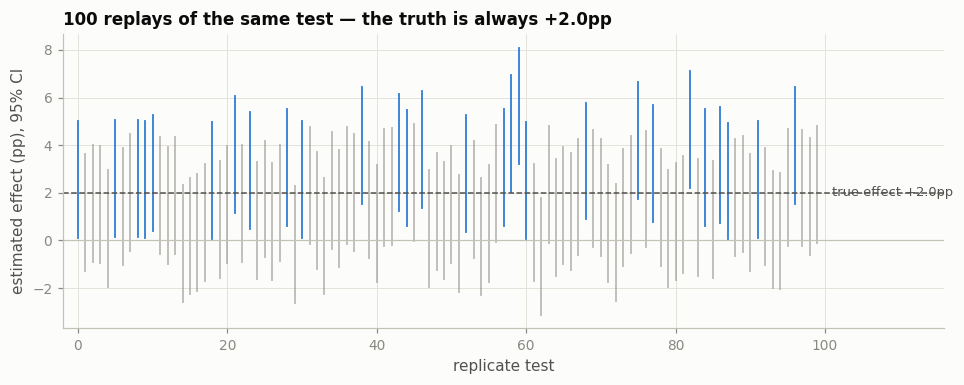

Grey intervals (65%) would be read as 'didn't work'. The wide interval is a POWER statement about the design, not a zero-effect finding.


In [3]:
R = 4000
ests = rng.normal(TRUE_EFFECT, se, R)          # sampling distribution of the estimate
crosses = np.abs(ests / se) < 1.96
print(f"True effect fixed at +{TRUE_EFFECT}pp, same design, {R:,} replays:")
print(f"  CIs crossing zero ('didn't work' verdicts): {crosses.mean():.0%}")
print(f"  Power at this design: {1 - crosses.mean():.0%}")

fig, ax = plt.subplots(figsize=(9, 3.6))
show = 100
lo, hi = ests[:show] - 1.96 * se, ests[:show] + 1.96 * se
for i in range(show):
    col = C["muted"] if lo[i] < 0 < hi[i] else C["blue"]
    ax.plot([i, i], [lo[i], hi[i]], color=col, lw=1.2,
            alpha=0.55 if col == C["muted"] else 0.95)
ax.axhline(0, color=C["axis"], lw=0.8)
ax.axhline(TRUE_EFFECT, color=C["ink2"], lw=1.0, ls="--")
ax.text(show + 1, TRUE_EFFECT, "true effect +2.0pp", va="center",
        fontsize=8.5, color=C["ink2"])
ax.set_title("100 replays of the same test — the truth is always +2.0pp")
ax.set_xlabel("replicate test")
ax.set_ylabel("estimated effect (pp), 95% CI")
ax.set_xlim(-2, show + 16)
plt.tight_layout(); plt.show()

msg = (f"Grey intervals ({crosses.mean():.0%}) would be read as 'didn't work'. "
       "The wide interval is a POWER statement about the design, not a zero-effect finding.")
print(msg)

## 3. The fix: a posterior, not a verdict

Conjugate normal update (no PyMC needed). Prior: margin moves of this kind
rarely shift contribution more than ±6pp → `N(0, 3²)`. Then check the answer
is not an artefact of the prior.

In [4]:
def posterior(prior_mu, prior_sd, obs, obs_se):
    w_p, w_d = 1 / prior_sd**2, 1 / obs_se**2
    var = 1 / (w_p + w_d)
    mu = var * (prior_mu * w_p + obs * w_d)
    return mu, np.sqrt(var)

post_mu, post_sd = posterior(0.0, 3.0, est, se)
p_pos = 1 - stats.norm.cdf(0, post_mu, post_sd)
p_bad = stats.norm.cdf(-1.0, post_mu, post_sd)
print(f"Posterior: {post_mu:+.2f}pp ± {post_sd:.2f}")
print(f"P(effect > 0)        = {p_pos:.0%}")
print(f"P(effect < -1pp)     = {p_bad:.1%}   (material downside)")

print("\nPrior sensitivity (the Head of Data will ask):")
for psd in (1.5, 3.0, 6.0):
    m, s = posterior(0.0, psd, est, se)
    print(f"  prior sd {psd:>3}:  posterior {m:+.2f} ± {s:.2f},  P(>0) = "
          f"{1 - stats.norm.cdf(0, m, s):.0%}")

Posterior: +1.70pp ± 1.16
P(effect > 0)        = 93%
P(effect < -1pp)     = 1.0%   (material downside)

Prior sensitivity (the Head of Data will ask):
  prior sd 1.5:  posterior +1.18 ± 0.96,  P(>0) = 89%
  prior sd 3.0:  posterior +1.70 ± 1.16,  P(>0) = 93%
  prior sd 6.0:  posterior +1.92 ± 1.23,  P(>0) = 94%


## 4. From posterior to £ — the decision, priced

The tested scope is the **branch estate** (retail + Post Office). Pull the
annual contribution base straight from the case-study engine, then price two
options under the posterior:

* **A — roll out now, with monitoring.** Upside runs 12 months; if the true
  effect is negative, monitoring catches it in ~8 weeks and we roll back
  (bounded, reversible downside + a rollback cost).
* **B — extend the test 4 weeks.** Halves the standard error, but pays a delay
  cost and a test-ops cost. Decide after the new data; roll out only if
  P(effect > 0) ≥ 75%.

In [5]:
from travel_money_simulator import generate_channel_panel
from distribution_economics import channel_pnl

panel = generate_channel_panel()                     # 2-year channel x day panel
pnl = channel_pnl(panel)
scope_2y = pnl.loc[["retail", "post_office"], "contribution"].sum()
BASE = scope_2y / 2 / 1e6                            # £m annual contribution in scope
print(f"Annual contribution in tested scope (retail + Post Office): £{BASE:,.1f}m")

ROLLBACK_COST, TEST_COST = 0.075, 0.025              # £m
DETECT_WK, HORIZON_WK, EXTEND_WK = 8, 52, 4

draws = rng.normal(post_mu, post_sd, 20_000)         # posterior over the true effect

def value_rollout(e, weeks_live):
    """£m value of rolling out, given true effect e (pp) and live weeks."""
    up = e / 100 * BASE * (weeks_live / HORIZON_WK)
    down = e / 100 * BASE * (DETECT_WK / HORIZON_WK) - ROLLBACK_COST
    return np.where(e >= 0, up, down)

# Option A: live for the full year.
ev_a = value_rollout(draws, HORIZON_WK).mean()

# Option B: extend, observe, then decide (pre-posterior / value-of-information).
se2 = se * np.sqrt(4 / 4)                            # 4 more weeks ~ same-size sample
obs2 = rng.normal(draws, se2)                        # what the extension would show
mu2 = np.empty_like(draws); sd2 = np.empty_like(draws)
for i, o in enumerate(obs2):                         # combine both observations
    m1, s1 = posterior(0.0, 3.0, est, se)
    mu2[i], sd2[i] = posterior(m1, s1, o, se2)
go = (1 - stats.norm.cdf(0, mu2, sd2)) >= 0.75
ev_b = (np.where(go, value_rollout(draws, HORIZON_WK - EXTEND_WK), 0.0)).mean() - TEST_COST

q = np.percentile(draws / 100 * BASE, [10, 50, 90])
print(f"\nAnnualised £ impact if rolled out:  P10 £{q[0]:+.2f}m | "
      f"P50 £{q[1]:+.2f}m | P90 £{q[2]:+.2f}m")
print(f"EV  A (roll out now, monitored):  £{ev_a:+.3f}m")
print(f"EV  B (extend 4 weeks, then decide):  £{ev_b:+.3f}m")
print(f"Value of more information: £{ev_b - ev_a:+.3f}m  ->  "
      f"{'EXTEND' if ev_b > ev_a else 'ROLL OUT NOW (monitored)'}")
worst = value_rollout(np.array([np.percentile(draws, 1)]), HORIZON_WK)[0]
print(f"Bounded downside (1st percentile truth, 8-week detection): £{worst:+.2f}m")

Annual contribution in tested scope (retail + Post Office): £64.8m

Annualised £ impact if rolled out:  P10 £+0.15m | P50 £+1.10m | P90 £+2.08m
EV  A (roll out now, monitored):  £+1.127m
EV  B (extend 4 weeks, then decide):  £+0.997m
Value of more information: £-0.130m  ->  ROLL OUT NOW (monitored)
Bounded downside (1st percentile truth, 8-week detection): £-0.17m


## 5. The chart the CFO reads in five seconds

No p-values anywhere on it. A range, a recommendation, and the floor.

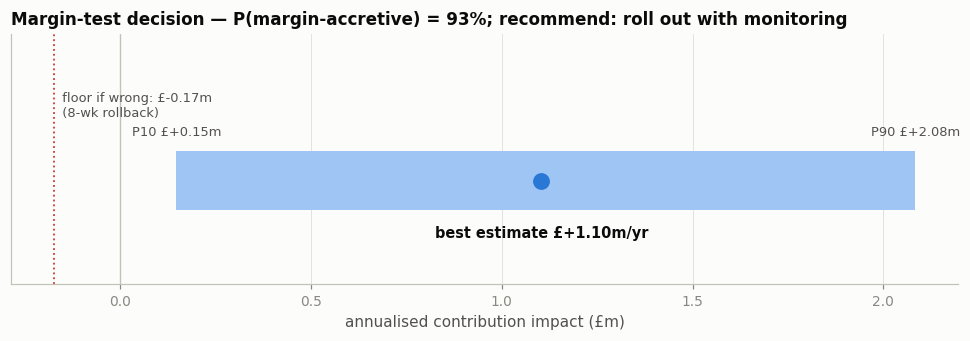

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh([0], [q[2] - q[0]], left=[q[0]], height=0.34,
        color=C["seq"][1], edgecolor="none")
ax.plot([q[1]], [0], "o", color=C["blue"], ms=10, zorder=5)
ax.axvline(0, color=C["axis"], lw=0.9)
ax.axvline(worst, color=C["critical"], lw=1.2, ls=":")
ax.text(worst, 0.35, f"  floor if wrong: £{worst:+.2f}m\n  (8-wk rollback)",
        fontsize=8.5, color=C["ink2"], va="bottom")
ax.text(q[1], -0.33, f"best estimate £{q[1]:+.2f}m/yr", ha="center",
        fontsize=9.5, color=C["ink"], fontweight="bold")
ax.text(q[0], 0.26, f"P10 £{q[0]:+.2f}m", ha="center", fontsize=8.5, color=C["ink2"])
ax.text(q[2], 0.26, f"P90 £{q[2]:+.2f}m", ha="center", fontsize=8.5, color=C["ink2"])
ax.set_title(f"Margin-test decision — P(margin-accretive) = {p_pos:.0%}; "
             f"recommend: roll out with monitoring")
ax.set_yticks([]); ax.set_xlabel("annualised contribution impact (£m)")
ax.set_ylim(-0.6, 0.85)
plt.tight_layout(); plt.show()

## The 60-second answer

> "Our best estimate is +2% margin; the plausible range runs from slightly
> negative to strongly positive. I wouldn't call that 'not significant, so it
> didn't work' — at this design, a true +2% effect would *fail* significance
> about two-thirds of the time, so the wide interval is telling us about the
> test's power, not about the effect.
>
> Framed as a decision: there's roughly a 90% probability the change is
> margin-accretive, worth about £1.1m a year at the median on this scope. The
> downside is bounded — if we're wrong, monitoring catches it in eight weeks
> and we roll back, capping the loss at a few hundred thousand. I priced the
> option of extending the test four weeks, and the extra information is worth
> less than the delay costs. So my recommendation is: **roll out with
> monitoring and a rollback trigger** — and design the next test with more
> regions or a longer window so we're not in this position again."

### What I'd say if pushed deeper

1. **"Isn't the posterior just your prior?"** — I checked: with prior sds of
   1.5, 3 and 6pp, P(effect > 0) stays around 85–93%. The data dominates. If it
   didn't, that itself would say the test is too weak to decide on.
2. **"What if the effect decays or the network games it?"** — The +2% is a
   branch-level, 4-week estimate; realised effects usually come in below
   estimated (regime shifts, competitor response). That's exactly why the
   rollout keeps a monitored holdout — it trues up the number in production.
3. **Honest limitation.** The bounded-downside claim depends on the 8-week
   detection lag and a clean rollback. If POS lead times or partner
   communications make rollback slow, the floor drops — I'd confirm the
   operational rollback path with the network team *before* shipping, not after.